In [9]:
import sys
import os

# Add backend directory to sys.path
sys.path.insert(0, os.path.abspath("../../../.."))

from langgraph.graph import StateGraph, END
from src.agents.store_manager_llm.state import WikiState

# Import all nodes
from src.agents.store_manager_llm.nodes.scan_sources import scan_sources
from src.agents.store_manager_llm.nodes.classify_sources import classify_sources
from src.agents.store_manager_llm.nodes.extract_entities import extract_entities
from src.agents.store_manager_llm.nodes.extract_reviews import extract_reviews
from src.agents.store_manager_llm.nodes.search_existing_wiki import search_existing_wiki
from src.agents.store_manager_llm.nodes.knowledge_diff import knowledge_diff
from src.agents.store_manager_llm.nodes.create_pages import create_pages
from src.agents.store_manager_llm.nodes.update_pages import update_pages
from src.agents.store_manager_llm.nodes.resolve_conflicts import resolve_conflicts
from src.agents.store_manager_llm.nodes.cross_reference import cross_reference
from src.agents.store_manager_llm.nodes.update_index import update_index
from src.agents.store_manager_llm.nodes.append_log import append_log
from src.agents.store_manager_llm.nodes.validate_wiki import validate_wiki


In [ ]:
# !pip install slugify
# !pip install rapidfuzz

  Using cached rapidfuzz-3.14.5-cp310-cp310-win_amd64.whl.metadata (12 kB)
Using cached rapidfuzz-3.14.5-cp310-cp310-win_amd64.whl (1.5 MB)


In [10]:
"""
graph.py — LangGraph definition for the Wiki Maintainer Agent.

Graph topology:
  scan_sources → classify_sources → extract_entities → extract_reviews
  → search_existing_wiki → knowledge_diff
  → [conditional: create_pages / update_pages / both]
  → resolve_conflicts → cross_reference → update_index → append_log
  → validate_wiki → END

The conditional edge after knowledge_diff routes based on
whether pages_to_create and/or pages_to_update are populated.
"""

def _route_after_diff(state: WikiState) -> str:
    """
    Conditional routing after knowledge_diff.
    Routes to create_pages, update_pages, or both.
    If neither has items, skip to resolve_conflicts.
    """
    has_creates = bool(state.get("pages_to_create"))
    has_updates = bool(state.get("pages_to_update"))

    if has_creates and has_updates:
        return "create_pages"  # create first, then update
    elif has_creates:
        return "create_pages"
    elif has_updates:
        return "update_pages"
    else:
        return "resolve_conflicts"  # nothing to create or update


def _route_after_create(state: WikiState) -> str:
    """After creating pages, check if we also need to update."""
    if state.get("pages_to_update"):
        return "update_pages"
    return "resolve_conflicts"



"""
Build and compile the LangGraph for wiki maintenance.

Returns a compiled graph ready to invoke.
"""
graph = StateGraph(WikiState)

# ── Add all nodes ────────────────────────────────────────────────────
graph.add_node("scan_sources", scan_sources)
graph.add_node("classify_sources", classify_sources)
graph.add_node("extract_entities", extract_entities)
graph.add_node("extract_reviews", extract_reviews)
graph.add_node("search_existing_wiki", search_existing_wiki)
graph.add_node("knowledge_diff", knowledge_diff)
graph.add_node("create_pages", create_pages)
graph.add_node("update_pages", update_pages)
graph.add_node("resolve_conflicts", resolve_conflicts)
graph.add_node("cross_reference", cross_reference)
graph.add_node("update_index", update_index)
graph.add_node("append_log", append_log)
graph.add_node("validate_wiki", validate_wiki)

# ── Set entry point ──────────────────────────────────────────────────
graph.set_entry_point("scan_sources")

# ── Linear edges ─────────────────────────────────────────────────────
graph.add_edge("scan_sources", "classify_sources")
graph.add_edge("classify_sources", "extract_entities")
graph.add_edge("extract_entities", "extract_reviews")
graph.add_edge("extract_reviews", "search_existing_wiki")
graph.add_edge("search_existing_wiki", "knowledge_diff")

# ── Conditional edge: create / update / skip ─────────────────────────
graph.add_conditional_edges(
    "knowledge_diff",
    _route_after_diff,
    {
        "create_pages": "create_pages",
        "update_pages": "update_pages",
        "resolve_conflicts": "resolve_conflicts",
    }
)

# After create, optionally go to update
graph.add_conditional_edges(
    "create_pages",
    _route_after_create,
    {
        "update_pages": "update_pages",
        "resolve_conflicts": "resolve_conflicts",
    }
)

# After update, go to resolve
graph.add_edge("update_pages", "resolve_conflicts")

# ── Final linear edges ───────────────────────────────────────────────
graph.add_edge("resolve_conflicts", "cross_reference")
graph.add_edge("cross_reference", "update_index")
graph.add_edge("update_index", "append_log")
graph.add_edge("append_log", "validate_wiki")
graph.add_edge("validate_wiki", END)
wf =  graph.compile()


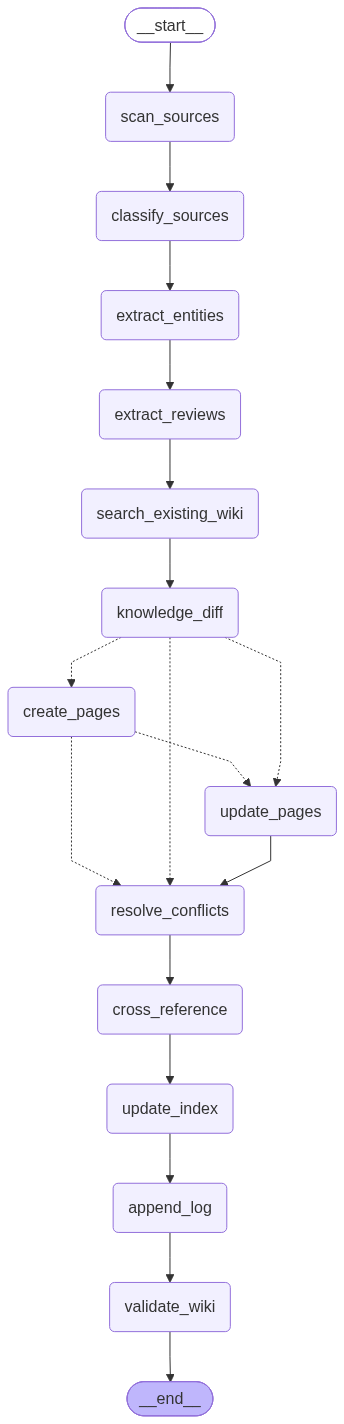

In [11]:
wf